# ENVI-met 내보내기 데모

이 노트북은 미세 기후 시뮬레이션을 위해 VoxCity 모델을 **ENVI-met INX** 형식으로 내보내는 방법을 보여줍니다.

Contents:
0. 환경 준비 (Google Colab)
1. VoxCity 모델 생성 또는 불러오기
2. 기본 INX 내보내기 (기본 설정)
3. 식생 데이터베이스(EDB 파일) 생성
4. 토지 피복 → ENVI-met ID 매핑 사용자 정의
5. 건물 자재(벽면 및 지붕) 및 옥상 녹화 사용자 정의
6. 그리드 설정 구성 (Telescoping, 수직 신축)
7. 종합 예시
8. 참고: 사용 가능한 토양 프로필 ID

## 0. 환경 준비 (Google Colab)

In [ ]:
#@title 0.1. voxcity 설치
!pip install voxcity
!apt-get update
!apt-get install -y xvfb libgl1-mesa-glx

In [ ]:
#@title 0.2. Google Earth Engine 인증 (링크를 클릭하여 토큰을 생성하고 복사하여 붙여넣으세요)
!earthengine authenticate --auth_mode=notebook

## 0.3. 대상 구역 설정

좌표를 직접 설정하려면 **옵션 1**을, 대화형 지도에서 사각형을 그리려면 **옵션 2**를 선택하세요.

### 옵션 1: 각 꼭짓점 좌표 설정

In [1]:
rectangle_vertices = [
    (139.7600, 35.6800),  # 남서쪽 모서리 (경도, 위도)
    (139.7600, 35.6900),  # 북서쪽 모서리
    (139.7700, 35.6900),  # 북동쪽 모서리
    (139.7700, 35.6800),  # 남동쪽 모서리
]

### 옵션 2: 지도에서 사각형 그리기
패널을 사용하여 도시를 설정하고, 그리기 모드(정렬/회전/고정)를 전환하며, 크기를 조정하세요.

In [ ]:
from voxcity.geoprocessor.draw import create_rectangle_map

ui, rectangle_vertices = create_rectangle_map()
ui

## 1. VoxCity 모델 생성 또는 불러오기

새 모델을 생성하려면 **옵션 A**를, 이전에 저장된 모델을 불러오려면 **옵션 B**를 선택하세요.

**`dem_source`**: ENVI-met 시뮬레이션의 경우 평탄한 지형(`dem_source="Flat"`)을 사용하는 것이 권장됩니다. ENVI-met V5.7.1은 복잡한 지형에 대해 비물리적인 결과를 예측하는 경우가 많으므로( [ENVI-met 문서](http://www.envi-hq.com/) 참조), ENVI-met 시뮬레이션 수행 시 DEM을 사용하지 않을 것을 강력히 권장합니다. 연구 구역에 상당한 고도 차이가 있는 경우 다른 DEM 소스(예: `"NASA"`, `"COPERNICUS"`, `"FABDEM"`)를 지정할 수 있지만 주의해서 사용하십시오.

**`remove_perimeter_object`** (선택 사항, 0에서 1 사이의 실수): 부분적으로 잘린 건물이나 수관으로 인한 경계 아티팩트를 방지하기 위해 그리드 가장자리 근처의 객체를 제거합니다. 이 값은 제거 구역의 너비로 사용될 그리드 크기의 비율을 지정합니다. 예를 들어, `0.1`은 각 측면의 외부 10% 이내에 있는 모든 객체를 제거합니다. 경계 구역 내부에서는:
- 해당 구역에 닿는 **건물**은 전체가 제거됩니다 (내부로 확장된 부분 포함)

- **나무** (수관)가 제거됩니다. - **토지 피복**은 "Developed space" (클래스 11)로 설정됩니다.

[Taichi] version 1.7.4, llvm 15.0.1, commit b4b956fd, win, python 3.12.9


INFO | voxcity.voxcity.generator.api | Auto-selecting data sources for: building_source, land_cover_source, canopy_height_source, dem_source, building_complementary_source


[Taichi] Starting on arch=cuda
Loading formatted geocoded file...


INFO | voxcity.voxcity.generator.api | Detected country for ROI center (139.7650, 35.6850): Japan
2026-04-10 14:31:11,774 - WARNING - Encountered 403 Forbidden with reason "PERMISSION_DENIED"
INFO | voxcity.voxcity.generator.api | Selected data sources:
INFO | voxcity.voxcity.generator.api | - Buildings(base)=OpenStreetMap | https://www.openstreetmap.org
INFO | voxcity.voxcity.generator.api | - Buildings(comp)=None
INFO | voxcity.voxcity.generator.api | - LandCover=OpenEarthMapJapan | https://www.open-earth-map.org/demo/Japan/leaflet.html
INFO | voxcity.voxcity.generator.api | - Canopy=Static
INFO | voxcity.voxcity.generator.api | - DEM=Flat
INFO | voxcity.voxcity.generator.api | - ComplementHeight=10


Creating Land Use Land Cover grid
 
Data source: OpenEarthMapJapan

OpenEarthMapJapan Land Cover Classes (source-specific, 0-based indices):
-------------------------------------------------------
   0: Bareland
   1: Rangeland
   2: Developed space
   3: Road
   4: Tree
   5: Water
   6: Agriculture land
   7: Building
-------------------------------------------------------
Note: These source-specific classes will be converted to
      VoxCity Standard Classes (1-14) during voxelization.

Access 2D land cover grid from VoxCity object:
  land_cover_grid = voxcity.land_cover.classes

Composing image with dimensions: 1024x1024
GeoTIFF saved as 'output\land_cover.tif' in Web Mercator projection (EPSG:3857).


c:\Users\kunih\miniconda3\envs\voxcity\Lib\site-packages\osgeo\gdal.py:606: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


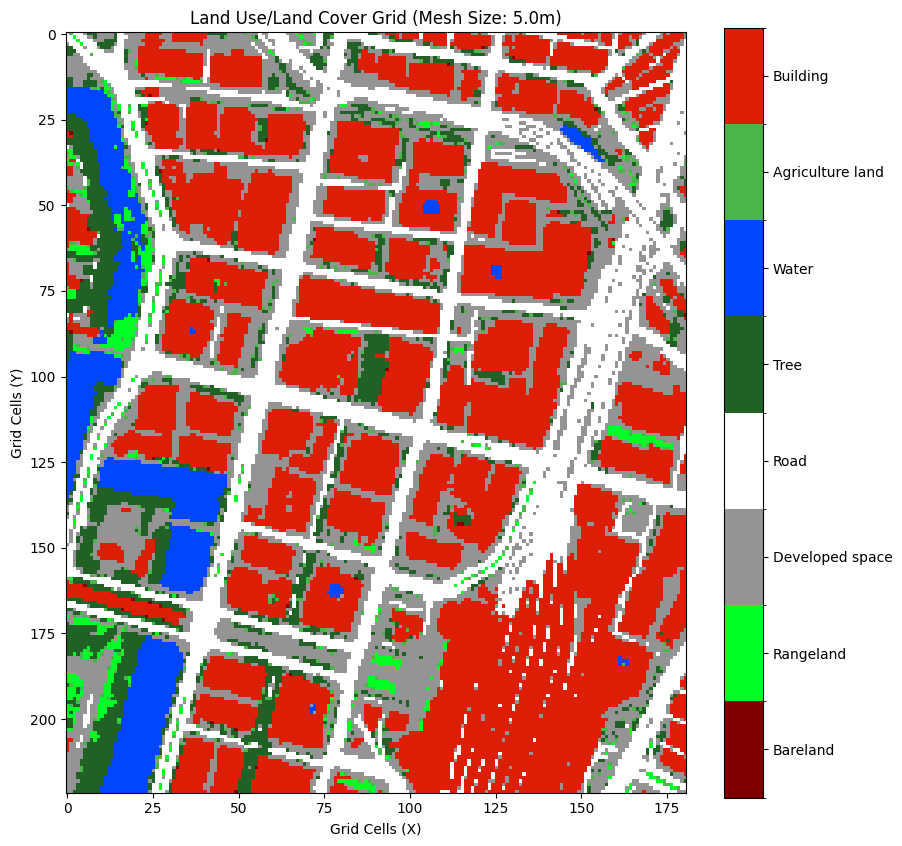

Creating Building Height grid
 
Base data source: OpenStreetMap
Complementary data source: None
239 of the total 351 building footprint from the base data source did not have height data.


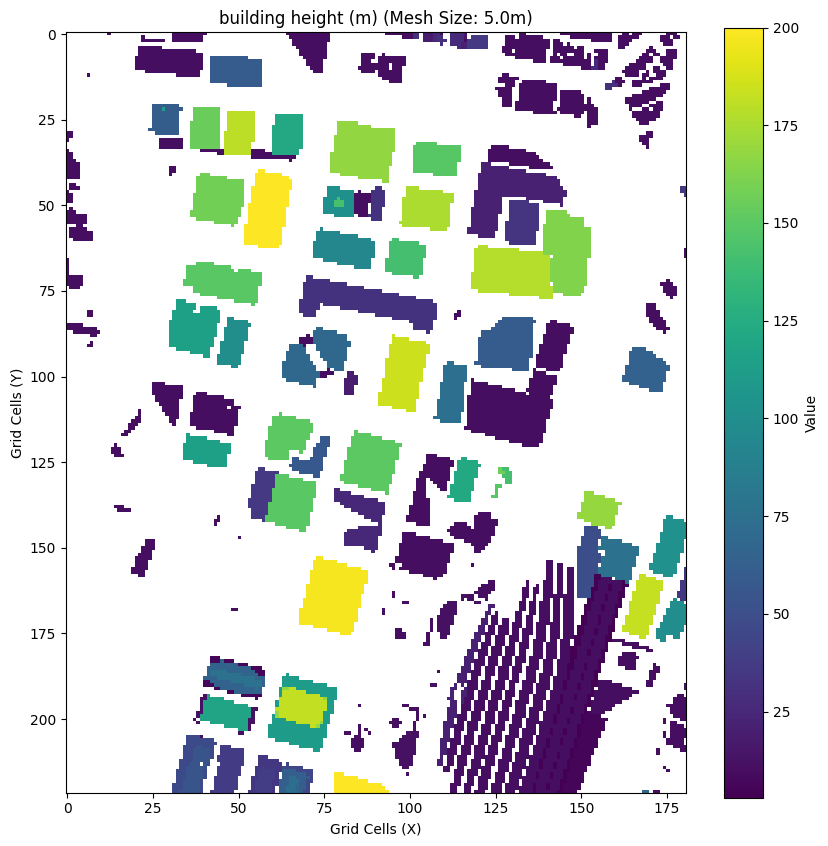

INFO | voxcity.voxcity.generator.voxelizer | Generating 3D voxel data
INFO | voxcity.voxcity.generator.voxelizer | 
Voxel Grid Semantic Codes:
  -3 : Building volume
  -2 : Tree canopy (vegetation)
  -1 : Ground/Subsurface
  >=1: Land cover class at ground surface (see Land Cover Classes)

INFO | voxcity.voxcity.generator.voxelizer | 
VoxCity Standard Land Cover Classes (1-based indices, used in voxel grids):
--------------------------------------------------
   1: Bareland           - Bare soil, rocks, desert
   2: Rangeland          - Grassland, pasture
   3: Shrub              - Shrubland, bushes
   4: Agriculture land   - Cropland, farmland
   5: Tree               - Forest, tree cover
   6: Moss and lichen    - Moss, lichen cover
   7: Wet land           - Wetland, marsh
   8: Mangrove           - Mangrove forest
   9: Water              - Water bodies
  10: Snow and ice       - Snow, ice, glaciers
  11: Developed space    - Urban areas, parking
  12: Road               - Roads, p

VoxCity 결과 저장 완료: output/voxcity.h5


In [ ]:
# 옵션 A: 새 모델 생성
from voxcity.generator import get_voxcity

meshsize = 5  # 미터
voxcity = get_voxcity(rectangle_vertices, meshsize, dem_source="Flat", remove_perimeter_object=0.1)

In [ ]:
# 옵션 B: 이전에 저장된 모델 불러오기
# from voxcity.generator.io import load_voxcity
# voxcity = load_voxcity("output/voxcity.h5")

In [ ]:
#@title Visualize the generated 3D city model (This process may take a long time, so skip this step if you set a large target area)
from voxcity.visualizer import visualize_voxcity

visualize_voxcity(voxcity, mode="interactive")

: 

## 2. 기본 INX 내보내기 (기본 설정)

The simplest usage — export with all default ENVI-met IDs and grid settings.

In [ ]:
from voxcity.exporter.envimet import export_inx, generate_edb_file

output_directory = './output/envimet'
file_basename = 'voxcity'

# Export the INX model file
export_inx(voxcity, output_directory, file_basename)

print(f"INX file saved to {output_directory}/{file_basename}.INX")

## 3. 식생 데이터베이스(EDB 파일) 생성

ENVI-met needs a plant database (`.edb`) that defines the 3D tree models referenced in the INX file.
`generate_edb_file()` creates `projectdatabase.edb` with trees from 1–50 m height.

Parameters:
- `lad` — Leaf Area Density in m²/m³ (default: 1.0)
- `trunk_height_ratio` — ratio of trunk height to total tree height (default: 11.76/19.98 ≈ 0.59)
- `output_dir` — directory to write the file (default: current directory)

In [ ]:
# Generate with default LAD and save to the same output directory as the INX
generate_edb_file(
    lad=1.0,
    trunk_height_ratio=11.76 / 19.98,
    output_dir='./output/envimet'
)

print("EDB file saved to ./output/envimet/projectdatabase.edb")

In [ ]:
# Example: denser canopy with higher LAD
generate_edb_file(
    lad=2.0,
    output_dir='./output/envimet'
)

### How to use the EDB file in ENVI-met

After generating the `projectdatabase.edb` file, you need to register it as the **project database** in ENVI-met so that the 3D plant definitions (trees) are recognized.

**Steps:**

1. **Place the file** — Copy `projectdatabase.edb` into your ENVI-met project folder (the same folder that contains the `.INX` file), or note its location.

2. **Open ENVI-met** — Launch ENVI-met and open (or create) the project that will use your INX model.

3. **Set the project database** — Go to **Edit → Project Database** (or open the **Database Manager**). Use **File → Open** to load the `projectdatabase.edb` file. This tells ENVI-met where to find the custom tree definitions (e.g., `H05W01`, `H10W01`, …, `H50W01`).

4. **Load the INX model** — Open the generated `.INX` file in ENVI-met SPACES. The 3D plant IDs in the model will now resolve to the tree definitions in your EDB file.

5. **Verify** — In SPACES, check that trees appear correctly by inspecting the 3D plant layer. Each plant ID corresponds to a tree of a specific height (e.g., `H10W01` = 10 m tall tree).

> **Tip:** The EDB file and the INX file must be in the **same project folder** for ENVI-met to automatically discover the plant database. If they are in different locations, you will need to manually load the EDB via the Database Manager.

## 4. 토지 피복 → ENVI-met ID 매핑 사용자 정의

VoxCity uses a standard 14-class land cover classification. When exporting to ENVI-met,
each class is mapped to:
- A **vegetation (simple plant) ID** — the `<ID_plants1D>` grid
- A **soil profile / surface ID** — the `<ID_soilprofile>` grid

You can override any of these defaults using the `envimet_mapping` parameter.
Each key is the **1-based land cover class index**, and the value is a dict with
optional `'veg'` and/or `'mat'` keys.

> **Note:** Tree vegetation (class 5, `'veg'` key) cannot be customized here — trees are 
> handled as 3D plants via the EDB database.

### Default mapping reference

| Class | Land Cover     | Default veg ID | Default mat ID | Description              |
|------:|:---------------|:---------------|:---------------|:-------------------------|
| 1     | Bareland       | _(empty)_      | `000000`       | Default soil             |
| 2     | Rangeland      | `0200XX`       | `000000`       | Grass / default soil     |
| 3     | Shrub          | `0200H1`       | `000000`       | Hedge / default soil     |
| 4     | Agriculture    | `0200XX`       | `000000`       | Grass / default soil     |
| 5     | Tree           | _(3D plant)_   | `000000`       | Handled via EDB          |
| 6     | Moss/lichen    | `0200XX`       | `000000`       | Grass / default soil     |
| 7     | Wetland        | `0200XX`       | `0200WW`       | Grass / water            |
| 8     | Mangrove       | _(empty)_      | `0200WW`       | Water                    |
| 9     | Water          | —              | `0200WW`       | Water                    |
| 10    | Snow/ice       | —              | `000000`       | Default soil             |
| 11    | Developed      | —              | `0200PG`       | Concrete pavement gray   |
| 12    | Road           | —              | `0200ST`       | Asphalt road             |
| 13    | Building       | —              | `000000`       | Default soil             |
| 14    | No Data        | —              | `000000`       | Default soil             |

In [ ]:
# Example: customize specific land cover classes
envimet_mapping = {
    # Class 2 (Rangeland): use a different grass species
    2: {'veg': '0200XX'},

    # Class 11 (Developed): use lighter concrete pavement
    11: {'mat': '0200PL'},   # Concrete Pavement Light

    # Class 12 (Road): use red-coated asphalt
    12: {'mat': '0200AR'},   # Asphalt road with red coating

    # Class 7 (Wetland): change both veg and surface
    7: {'veg': '0200XX', 'mat': '0200WW'},
}

export_inx(
    voxcity,
    output_directory='./output/envimet_custom',
    file_basename='voxcity_custom',
    envimet_mapping=envimet_mapping,
)

print("Custom INX exported.")

## 5. Customize building materials (wall & roof)

ENVI-met applies a **common wall material** and **common roof material** to all buildings.
By default these are `000000` (ENVI-met system default: moderate insulation).

### Common wall material IDs

| ID       | Description                          |
|:---------|:-------------------------------------|
| `000000` | Default Wall - moderate insulation   |
| `0200MI` | Default Wall - moderate insulation   |
| `0200C1` | Concrete Wall (heavy)                |
| `0200C2` | Concrete wall (light weight)         |
| `0200B2` | Brick wall (burned)                  |
| `0200G4` | Clear Float glass (one layered)      |
| `0200GH` | Heat protection glass (one air layer)|

### Common roof material IDs

| ID       | Description                          |
|:---------|:-------------------------------------|
| `000000` | Default Wall - moderate insulation   |
| `0200R1` | Roofing: Tile                        |
| `0200C1` | Concrete Wall (heavy)                |
| `0200AL` | Aluminium (single layer)             |

In [ ]:
# Example: set brick walls with tile roof
export_inx(
    voxcity,
    output_directory='./output/envimet_materials',
    file_basename='voxcity_brick',
    common_wall_material='0200B2',   # Brick wall (burned)
    common_roof_material='0200R1',   # Roofing: Tile
)

print("INX with custom wall/roof materials exported.")

### Rooftop vegetation (green roofs)

By default, 1D vegetation (grass, shrubs, etc.) is **removed** from cells that contain buildings.
This prevents unrealistic ground-level plants from appearing inside building footprints.

Set `rooftop_vegetation=True` to **keep** 1D vegetation on building cells — useful for
modeling green roofs or rooftop gardens in ENVI-met.

In [ ]:
# Example: export with green roofs (keep 1D vegetation on building cells)
export_inx(
    voxcity,
    output_directory='./output/envimet_greenroof',
    file_basename='voxcity_greenroof',
    rooftop_vegetation=True,
)

print("INX with rooftop vegetation exported.")

## 6. Configure grid settings

ENVI-met supports a **telescoping grid** where vertical cell size increases above a certain height,
reducing total cell count while keeping fine resolution near the ground.

Parameters:
- `useTelescoping_grid` (bool) — enable/disable telescoping (default: `False`)
- `verticalStretch` (float) — percentage increase per cell above start height (default: 20%)
- `startStretch` (float) — height (m) to begin stretching (default: auto from max building height)
- `domain_building_max_height_ratio` (float) — ratio of domain height to max building (default: 3)
- `min_grids_Z` (int) — minimum number of vertical grid cells (default: 20)
- `author_name` (str) — author name in the INX metadata
- `model_description` (str) — description in the INX metadata

In [ ]:
# Example: telescoping grid with metadata
export_inx(
    voxcity,
    output_directory='./output/envimet_telescoping',
    file_basename='voxcity_tele',
    useTelescoping_grid=True,
    verticalStretch=20,         # 20% growth per cell
    startStretch=50,            # start stretching at 50m
    domain_building_max_height_ratio=3,
    min_grids_Z=30,
    author_name='VoxCity User',
    model_description='Telescoping grid demo',
)

print("Telescoping grid INX exported.")

## 7. 종합 예시

Combine all customization options — including rooftop vegetation — in a single export call.

In [ ]:
output_dir = './output/envimet_full'

# 1) Export INX with all customizations
export_inx(
    voxcity,
    output_directory=output_dir,
    file_basename='voxcity_full',
    # Land cover → ENVI-met ID overrides
    envimet_mapping={
        11: {'mat': '0200PL'},  # Developed → Concrete Pavement Light
        12: {'mat': '0200AR'},  # Road → Asphalt with red coating
    },
    # Building materials
    common_wall_material='0200B2',
    common_roof_material='0200R1',
    # Rooftop vegetation
    rooftop_vegetation=True,
    # Grid settings
    useTelescoping_grid=True,
    verticalStretch=20,
    min_grids_Z=25,
    # Metadata
    author_name='VoxCity User',
    model_description='Full customization demo',
)

# 2) Generate plant database in the same directory
generate_edb_file(
    lad=1.0,
    output_dir=output_dir,
)

print(f"All files saved to {output_dir}/")

print("  - voxcity_full.INX")
print("  - projectdatabase.edb")

## 8. 참고: 사용 가능한 토양 프로필 ID

These are the most commonly used ENVI-met soil profile IDs (for `'mat'` in `envimet_mapping`):

| ID       | Description                       |
|:---------|:----------------------------------|
| `000000` | Default Sandy Loam                |
| `0200ST` | Asphalt Road                      |
| `0200PP` | Pavement (Concrete), used/dirty   |
| `0200PG` | Concrete Pavement Gray            |
| `0200PL` | Concrete Pavement Light           |
| `0200PD` | Concrete Pavement Dark            |
| `0200WW` | Deep Water                        |
| `0200SL` | Default Unsealed Soil (Sandy Loam)|
| `0200LO` | Loamy Soil                        |
| `0200SD` | Sandy Soil                        |
| `0200KK` | Brick road (red stones)           |
| `0200KG` | Brick road (yellow stones)        |
| `0200GG` | Dark Granite Pavement             |
| `0200GS` | Granite Pavement (single stones)  |
| `0200G2` | Granite shining                   |
| `0200AR` | Asphalt road with red coating     |
| `0200BA` | Basalt Brick Road                 |
| `0200WD` | Wood Planks                       |
| `0200DW` | Darker Wood Planks                |